# 📊 LoanGuard — Keşifsel Veri Analizi (EDA)

**Amaç:** Kredi temerrüt veri setini derinlemesine inceleyerek;
- Veri kalitesini değerlendirmek (eksik değer, tekrar, tutarsızlık)
- Değişkenlerin dağılımlarını ve aralarındaki ilişkileri anlamak
- Aykırı değerleri (outlier) tespit etmek
- ML pipeline'ı için veri ön-işleme stratejisini belirlemek

**Veri Seti:** `Loan_default.csv` — 255.347 kredi başvurusu kaydı

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Görselleştirme konfigürasyonu
# ---------------------------------------------------------------------------
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "savefig.bbox": "tight",
    "savefig.dpi": 150,
})

# Renk paletleri
TARGET_COLORS = ["#27ae60", "#e74c3c"]           # Yeşil = Ödedi, Kırmızı = Temerrüt
PALETTE_MAIN = sns.color_palette("coolwarm", 10)  # Genel kullanım

# Çıktı klasörü
FIGURES_DIR = "../reports/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("✅ Kütüphaneler ve konfigürasyon yüklendi.")

✅ Kütüphaneler ve konfigürasyon yüklendi.


---
## 1. Veri Yükleme & İlk Bakış

Veri setini yükleyip genel yapısını inceliyoruz: boyut, sütun tipleri, ilk/son satırlar.

In [2]:
# ---------------------------------------------------------------------------
# Veri setini yükle
# ---------------------------------------------------------------------------
df = pd.read_csv("../data/raw/Loan_default.csv")

print(f"📐 Veri seti boyutu: {df.shape[0]:,} satır × {df.shape[1]} sütun")
print(f"💾 Bellek kullanımı: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()
df.head(10)

📐 Veri seti boyutu: 255,347 satır × 18 sütun
💾 Bellek kullanımı: 149.3 MB



,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
5,A9S62RQ7US,25,90298,90448,720,18,2,22.72,24,0.10,High School,Unemployed,Single,Yes,No,Business,Yes,1
6,H8GXPAOS71,38,111188,177025,429,80,1,19.11,12,0.16,Bachelor's,Unemployed,Single,Yes,No,Home,Yes,0
7,0HGZQKJ36W,56,126802,155511,531,67,4,8.15,60,0.43,PhD,Full-time,Married,No,No,Home,Yes,0
8,1R0N3LGNRJ,36,42053,92357,827,83,1,23.94,48,0.20,Bachelor's,Self-employed,Divorced,Yes,No,Education,No,1
9,CM9L1GTT2P,40,132784,228510,480,114,4,9.09,48,0.33,High School,Self-employed,Married,Yes,No,Other,Yes,0


In [3]:
# ---------------------------------------------------------------------------
# Sütun gruplarını tanımla (pipeline boyunca tekrar kullanılacak)
# ---------------------------------------------------------------------------
NUMERICAL_COLS = [
    "Age", "Income", "LoanAmount", "CreditScore",
    "MonthsEmployed", "NumCreditLines", "InterestRate",
    "LoanTerm", "DTIRatio"
]

CATEGORICAL_COLS = [
    "Education", "EmploymentType", "MaritalStatus",
    "HasMortgage", "HasDependents", "LoanPurpose", "HasCoSigner"
]

TARGET_COL = "Default"
ID_COL = "LoanID"

print(f"Sayısal sütunlar   ({len(NUMERICAL_COLS)}): {NUMERICAL_COLS}")
print(f"Kategorik sütunlar ({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}")
print(f"Hedef değişken      : {TARGET_COL}")
print(f"ID sütunu           : {ID_COL}")

Sayısal sütunlar   (9): ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
Kategorik sütunlar (7): ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']
Hedef değişken      : Default
ID sütunu           : LoanID


In [4]:
# ---------------------------------------------------------------------------
# Veri tipleri özeti
# ---------------------------------------------------------------------------
dtype_summary = pd.DataFrame({
    "Dtype": df.dtypes,
    "Non-Null": df.notnull().sum(),
    "Null": df.isnull().sum(),
    "Unique": df.nunique(),
    "Sample": [df[col].iloc[0] for col in df.columns]
})
dtype_summary

,Dtype,Non-Null,Null,Unique,Sample
LoanID,object,255347,0,255347,I38PQUQS96
Age,int64,255347,0,52,56
Income,int64,255347,0,114620,85994
LoanAmount,int64,255347,0,158729,50587
CreditScore,int64,255347,0,550,520
MonthsEmployed,int64,255347,0,120,80
NumCreditLines,int64,255347,0,4,4
InterestRate,float64,255347,0,2301,15.23
LoanTerm,int64,255347,0,5,36
DTIRatio,float64,255347,0,81,0.44


---
## 2. İstatistiksel Özet

Sayısal ve kategorik sütunların temel istatistiklerini inceliyoruz.

In [5]:
# ---------------------------------------------------------------------------
# Sayısal sütunlar — temel istatistikler
# ---------------------------------------------------------------------------
df[NUMERICAL_COLS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.50,14.99,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.30,38963.01,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.87,70840.71,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.26,158.90,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.54,34.64,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.50,1.12,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.49,6.64,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.03,16.97,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.50,0.23,0.1,0.30,0.50,0.70,0.9


In [6]:
# ---------------------------------------------------------------------------
# Kategorik sütunlar — frekans bilgileri
# ---------------------------------------------------------------------------
df[CATEGORICAL_COLS].describe().T

,count,unique,top,freq
Education,255347,4,Bachelor's,64366
EmploymentType,255347,4,Part-time,64161
MaritalStatus,255347,3,Married,85302
HasMortgage,255347,2,Yes,127677
HasDependents,255347,2,Yes,127742
LoanPurpose,255347,5,Business,51298
HasCoSigner,255347,2,Yes,127701


---
## 3. Eksik Veri & Tekrar Kontrolü

Modelleme öncesinde veri kalitesinin kontrol edilmesi kritik bir adımdır.

In [7]:
# ---------------------------------------------------------------------------
# Eksik değer analizi
# ---------------------------------------------------------------------------
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing (%)": missing_pct
}).sort_values("Missing Count", ascending=False)

total_missing = missing_count.sum()
print(f"📋 Toplam eksik değer: {total_missing}")
print()
missing_report

📋 Toplam eksik değer: 0



,Missing Count,Missing (%)
LoanID,0,0.0
Age,0,0.0
HasCoSigner,0,0.0
LoanPurpose,0,0.0
HasDependents,0,0.0
HasMortgage,0,0.0
MaritalStatus,0,0.0
EmploymentType,0,0.0
Education,0,0.0
DTIRatio,0,0.0


In [8]:
# ---------------------------------------------------------------------------
# Tekrar eden satırlar & ID kontrolü
# ---------------------------------------------------------------------------
duplicate_rows = df.duplicated().sum()
duplicate_ids = df[ID_COL].duplicated().sum()

print(f"🔁 Tekrar eden satır sayısı : {duplicate_rows}")
print(f"🆔 Tekrar eden LoanID sayısı: {duplicate_ids}")

if duplicate_ids > 0:
    print("\n⚠️  Dikkat: Tekrar eden ID'ler mevcut! Bunlar incelenmelidir.")
else:
    print("\n✅ Her satır benzersiz bir LoanID'ye sahip.")

🔁 Tekrar eden satır sayısı : 0
🆔 Tekrar eden LoanID sayısı: 0

✅ Her satır benzersiz bir LoanID'ye sahip.


---
## 4. Hedef Değişken Analizi (Default)

Sınıf dengesizliğini (class imbalance) anlamak, modelleme stratejimizi doğrudan etkiler.
- **Default = 0** → Krediyi ödedi
- **Default = 1** → Temerrüte düştü

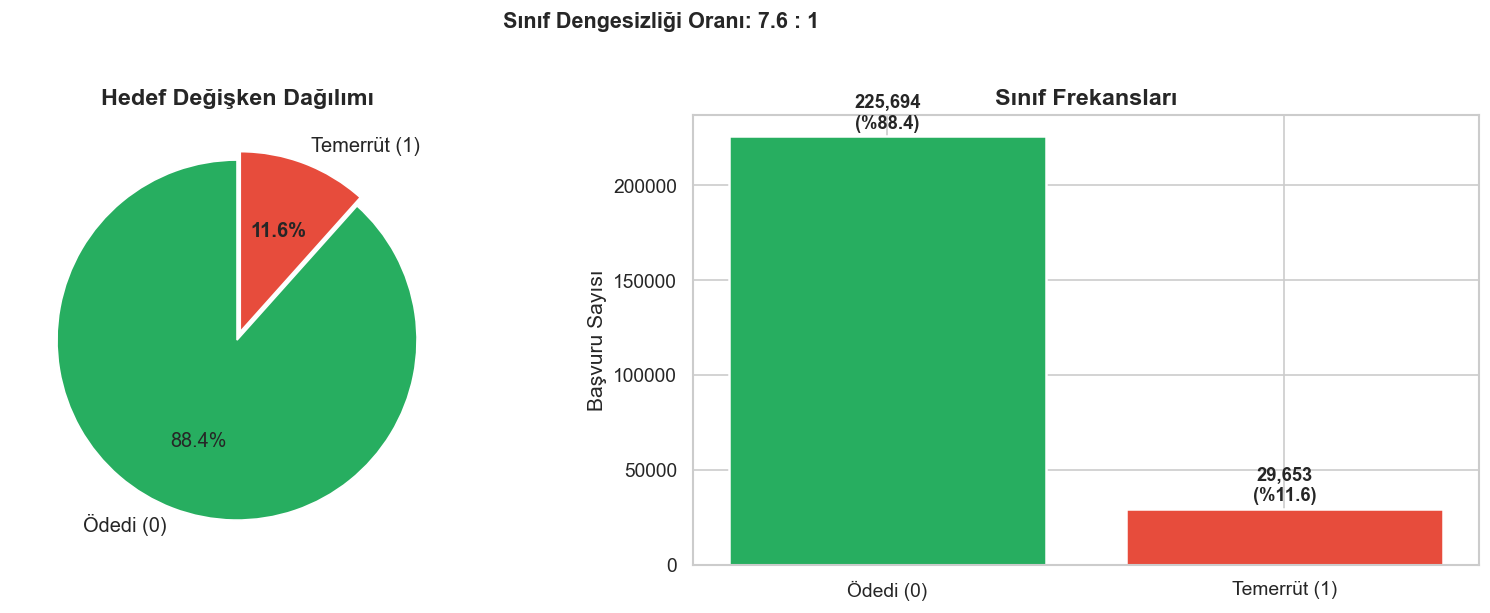


⚠️  Dengesizlik oranı: 7.6:1 → Modelde class_weight veya SMOTE kullanılmalı.


In [9]:
# ---------------------------------------------------------------------------
# Hedef değişken dağılımı — Pasta + Bar grafik
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_counts = df[TARGET_COL].value_counts()
target_labels = ["Ödedi (0)", "Temerrüt (1)"]
target_pcts = target_counts / len(df) * 100

# Sol: Pasta grafik
wedges, texts, autotexts = axes[0].pie(
    target_counts,
    labels=target_labels,
    autopct="%1.1f%%",
    colors=TARGET_COLORS,
    startangle=90,
    explode=(0, 0.05),
    textprops={"fontsize": 12}
)
autotexts[1].set_fontweight("bold")
axes[0].set_title("Hedef Değişken Dağılımı")

# Sağ: Bar grafik
bars = axes[1].bar(
    target_labels, target_counts.values,
    color=TARGET_COLORS, edgecolor="white", linewidth=1.5
)
for bar, count, pct in zip(bars, target_counts.values, target_pcts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
        f"{count:,}\n(%{pct:.1f})",
        ha="center", va="bottom", fontweight="bold", fontsize=11
    )
axes[1].set_title("Sınıf Frekansları")
axes[1].set_ylabel("Başvuru Sayısı")

imbalance_ratio = target_counts[0] / target_counts[1]
fig.suptitle(
    f"Sınıf Dengesizliği Oranı: {imbalance_ratio:.1f} : 1",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}01_target_distribution.png")
plt.show()

print(f"\n⚠️  Dengesizlik oranı: {imbalance_ratio:.1f}:1 → Modelde class_weight veya SMOTE kullanılmalı.")

---
## 5. Tek Değişkenli Analiz — Sayısal Sütunlar

Her sayısal sütunun dağılımını histogram ve KDE eğrisi ile görselleştiriyoruz.
Çarpıklık (skewness) ve aşırı sivrilik (kurtosis) değerleri de raporlanır.

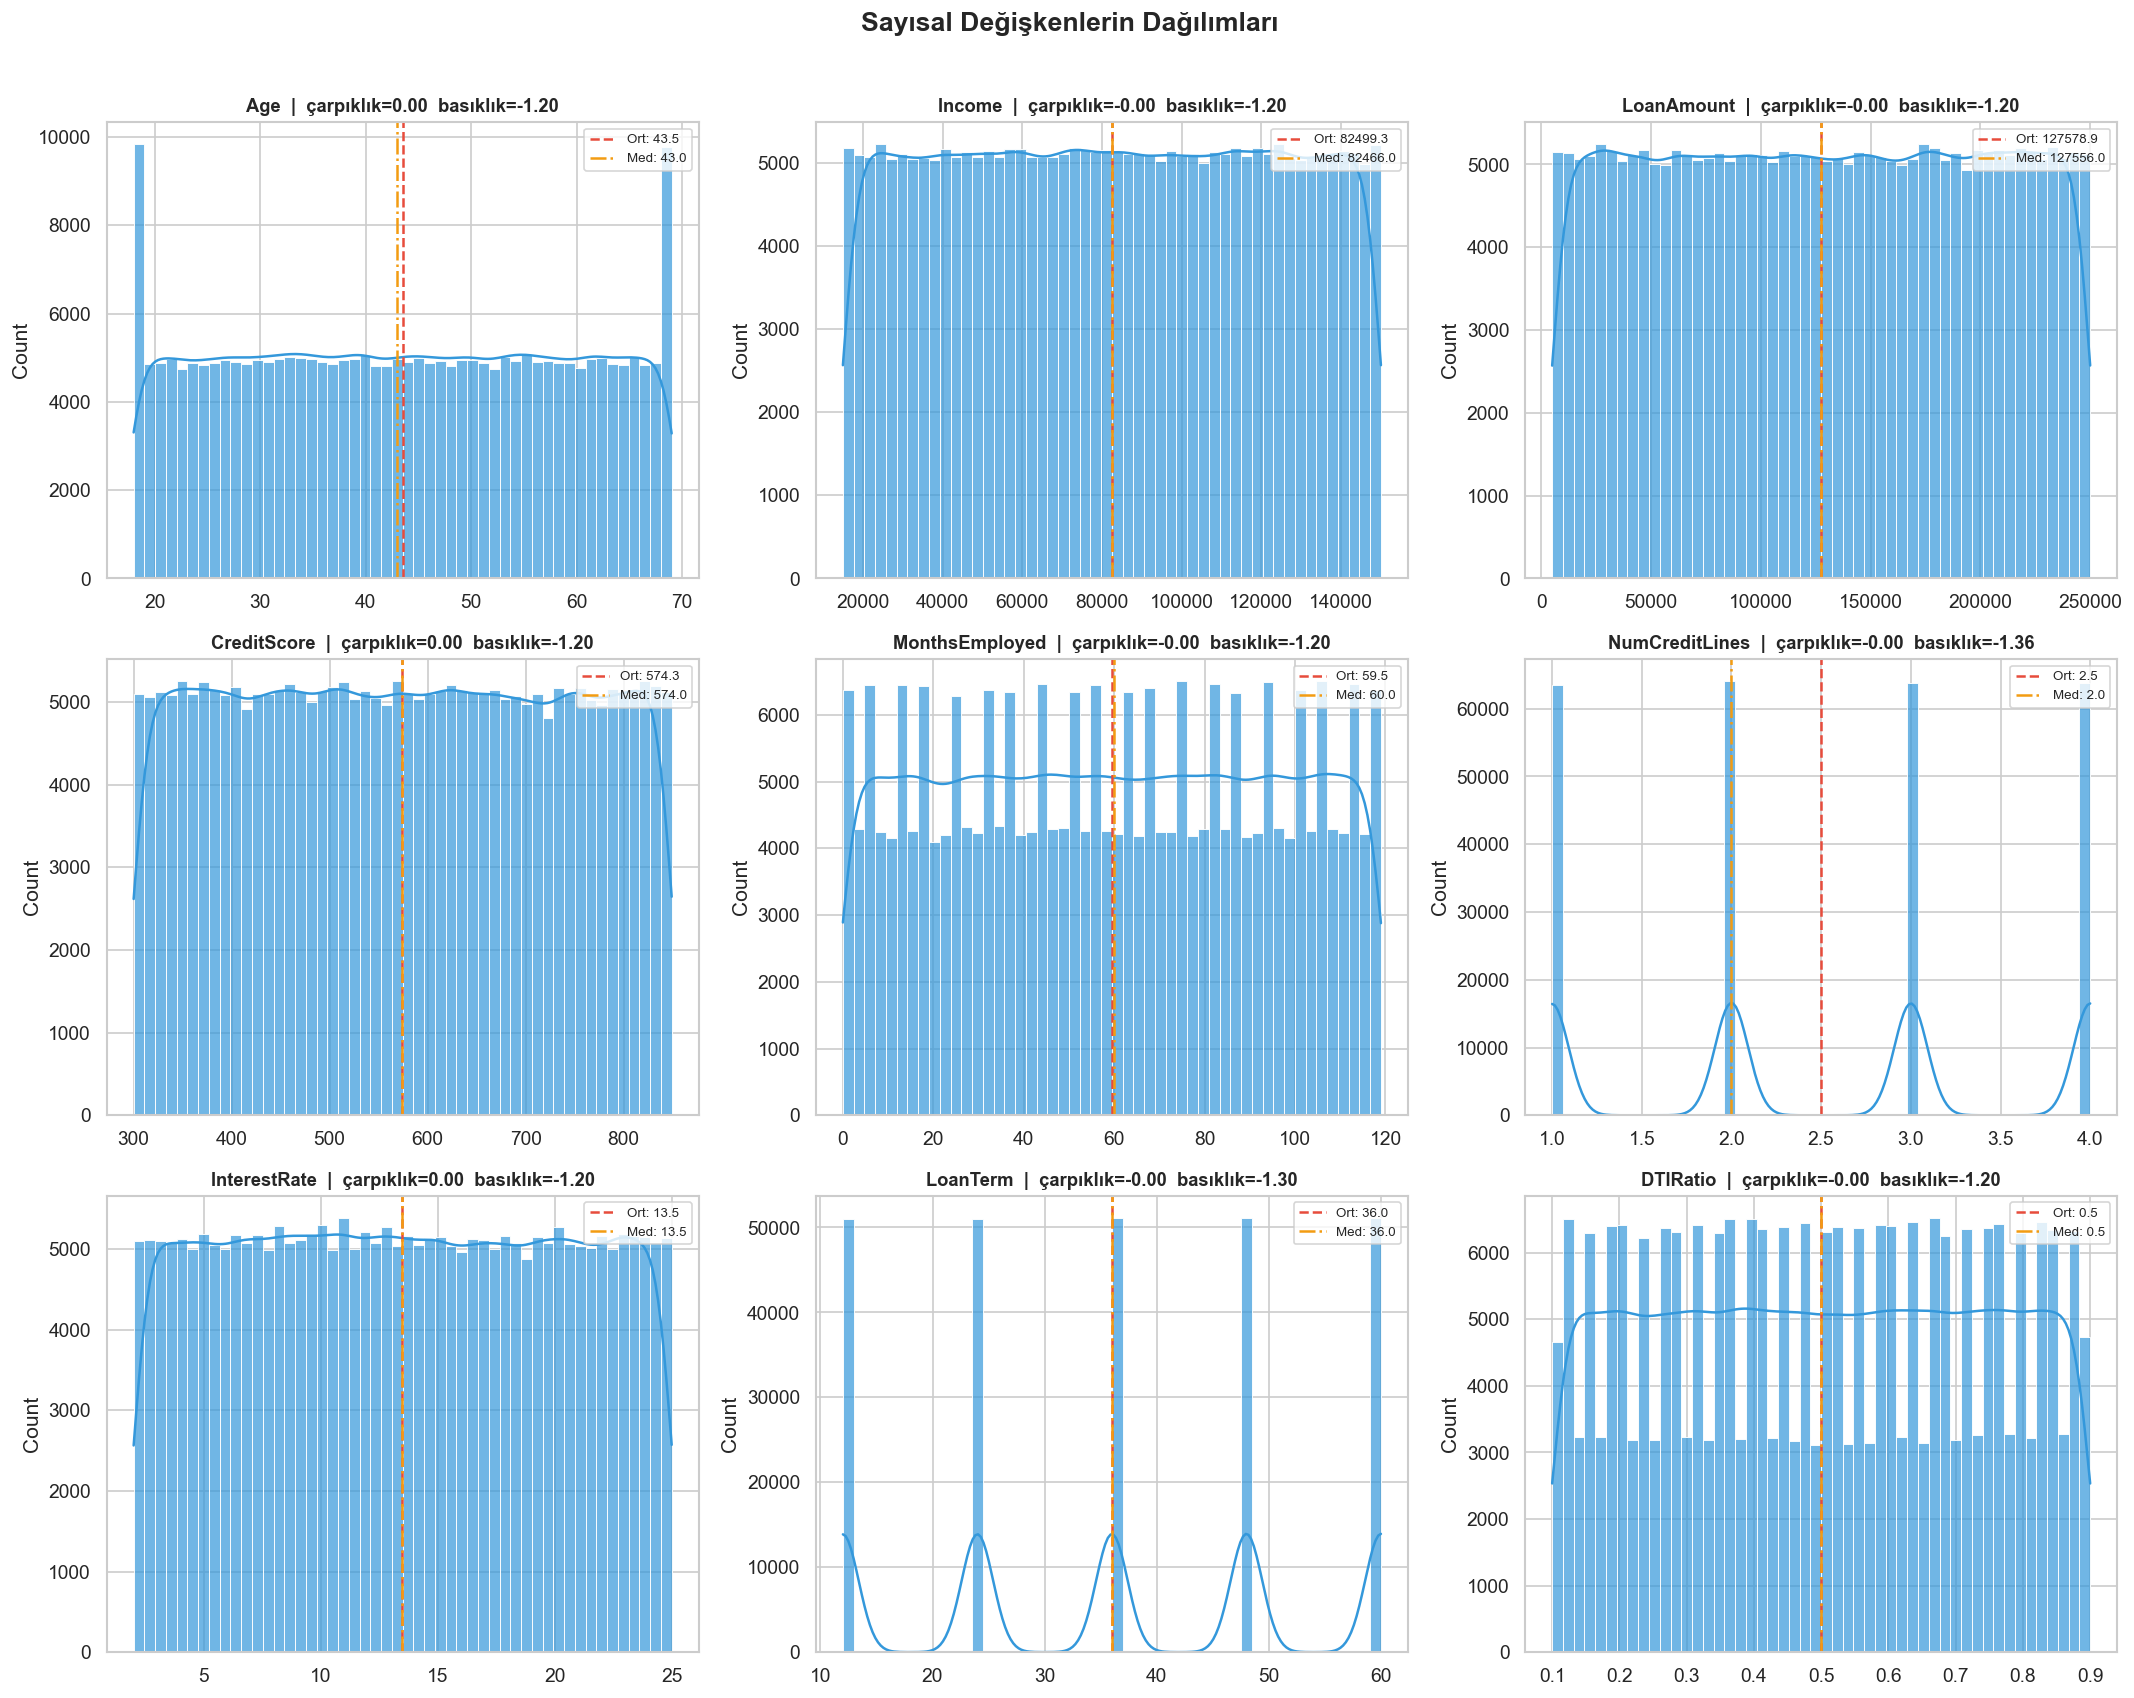

In [10]:
# ---------------------------------------------------------------------------
# Sayısal sütunlar — Histogram + KDE (3x3 grid)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_COLS):
    ax = axes[i]
    sns.histplot(df[col], bins=50, kde=True, ax=ax, color="#3498db", alpha=0.7)
    
    # İstatistikleri grafiğe ekle
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    ax.axvline(df[col].mean(), color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Ort: {df[col].mean():.1f}")
    ax.axvline(df[col].median(), color="#f39c12", linestyle="-.", linewidth=1.5, label=f"Med: {df[col].median():.1f}")
    ax.legend(fontsize=8, loc="upper right")
    ax.set_title(f"{col}  |  çarpıklık={skew:.2f}  basıklık={kurt:.2f}", fontsize=11)
    ax.set_xlabel("")

fig.suptitle("Sayısal Değişkenlerin Dağılımları", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}02_numerical_distributions.png")
plt.show()

In [11]:
# ---------------------------------------------------------------------------
# Çarpıklık & basıklık özet tablosu
# ---------------------------------------------------------------------------
skew_kurt_df = pd.DataFrame({
    "Mean": df[NUMERICAL_COLS].mean(),
    "Median": df[NUMERICAL_COLS].median(),
    "Std": df[NUMERICAL_COLS].std(),
    "Skewness": df[NUMERICAL_COLS].skew(),
    "Kurtosis": df[NUMERICAL_COLS].kurtosis(),
    "Min": df[NUMERICAL_COLS].min(),
    "Max": df[NUMERICAL_COLS].max()
}).round(3)

skew_kurt_df

,Mean,Median,Std,Skewness,Kurtosis,Min,Max
Age,43.498,43.00,14.990,0.001,-1.198,18.0,69.0
Income,82499.305,82466.00,38963.014,-0.000,-1.198,15000.0,149999.0
LoanAmount,127578.866,127556.00,70840.706,-0.002,-1.204,5000.0,249999.0
CreditScore,574.264,574.00,158.904,0.005,-1.200,300.0,849.0
MonthsEmployed,59.542,60.00,34.643,-0.002,-1.200,0.0,119.0
NumCreditLines,2.501,2.00,1.117,-0.000,-1.358,1.0,4.0
InterestRate,13.493,13.46,6.636,0.005,-1.197,2.0,25.0
LoanTerm,36.026,36.00,16.969,-0.002,-1.300,12.0,60.0
DTIRatio,0.500,0.50,0.231,-0.001,-1.200,0.1,0.9


---
## 6. Tek Değişkenli Analiz — Kategorik Sütunlar

Her kategorik sütundaki kategorilerin frekanslarını bar grafik ile inceliyoruz.

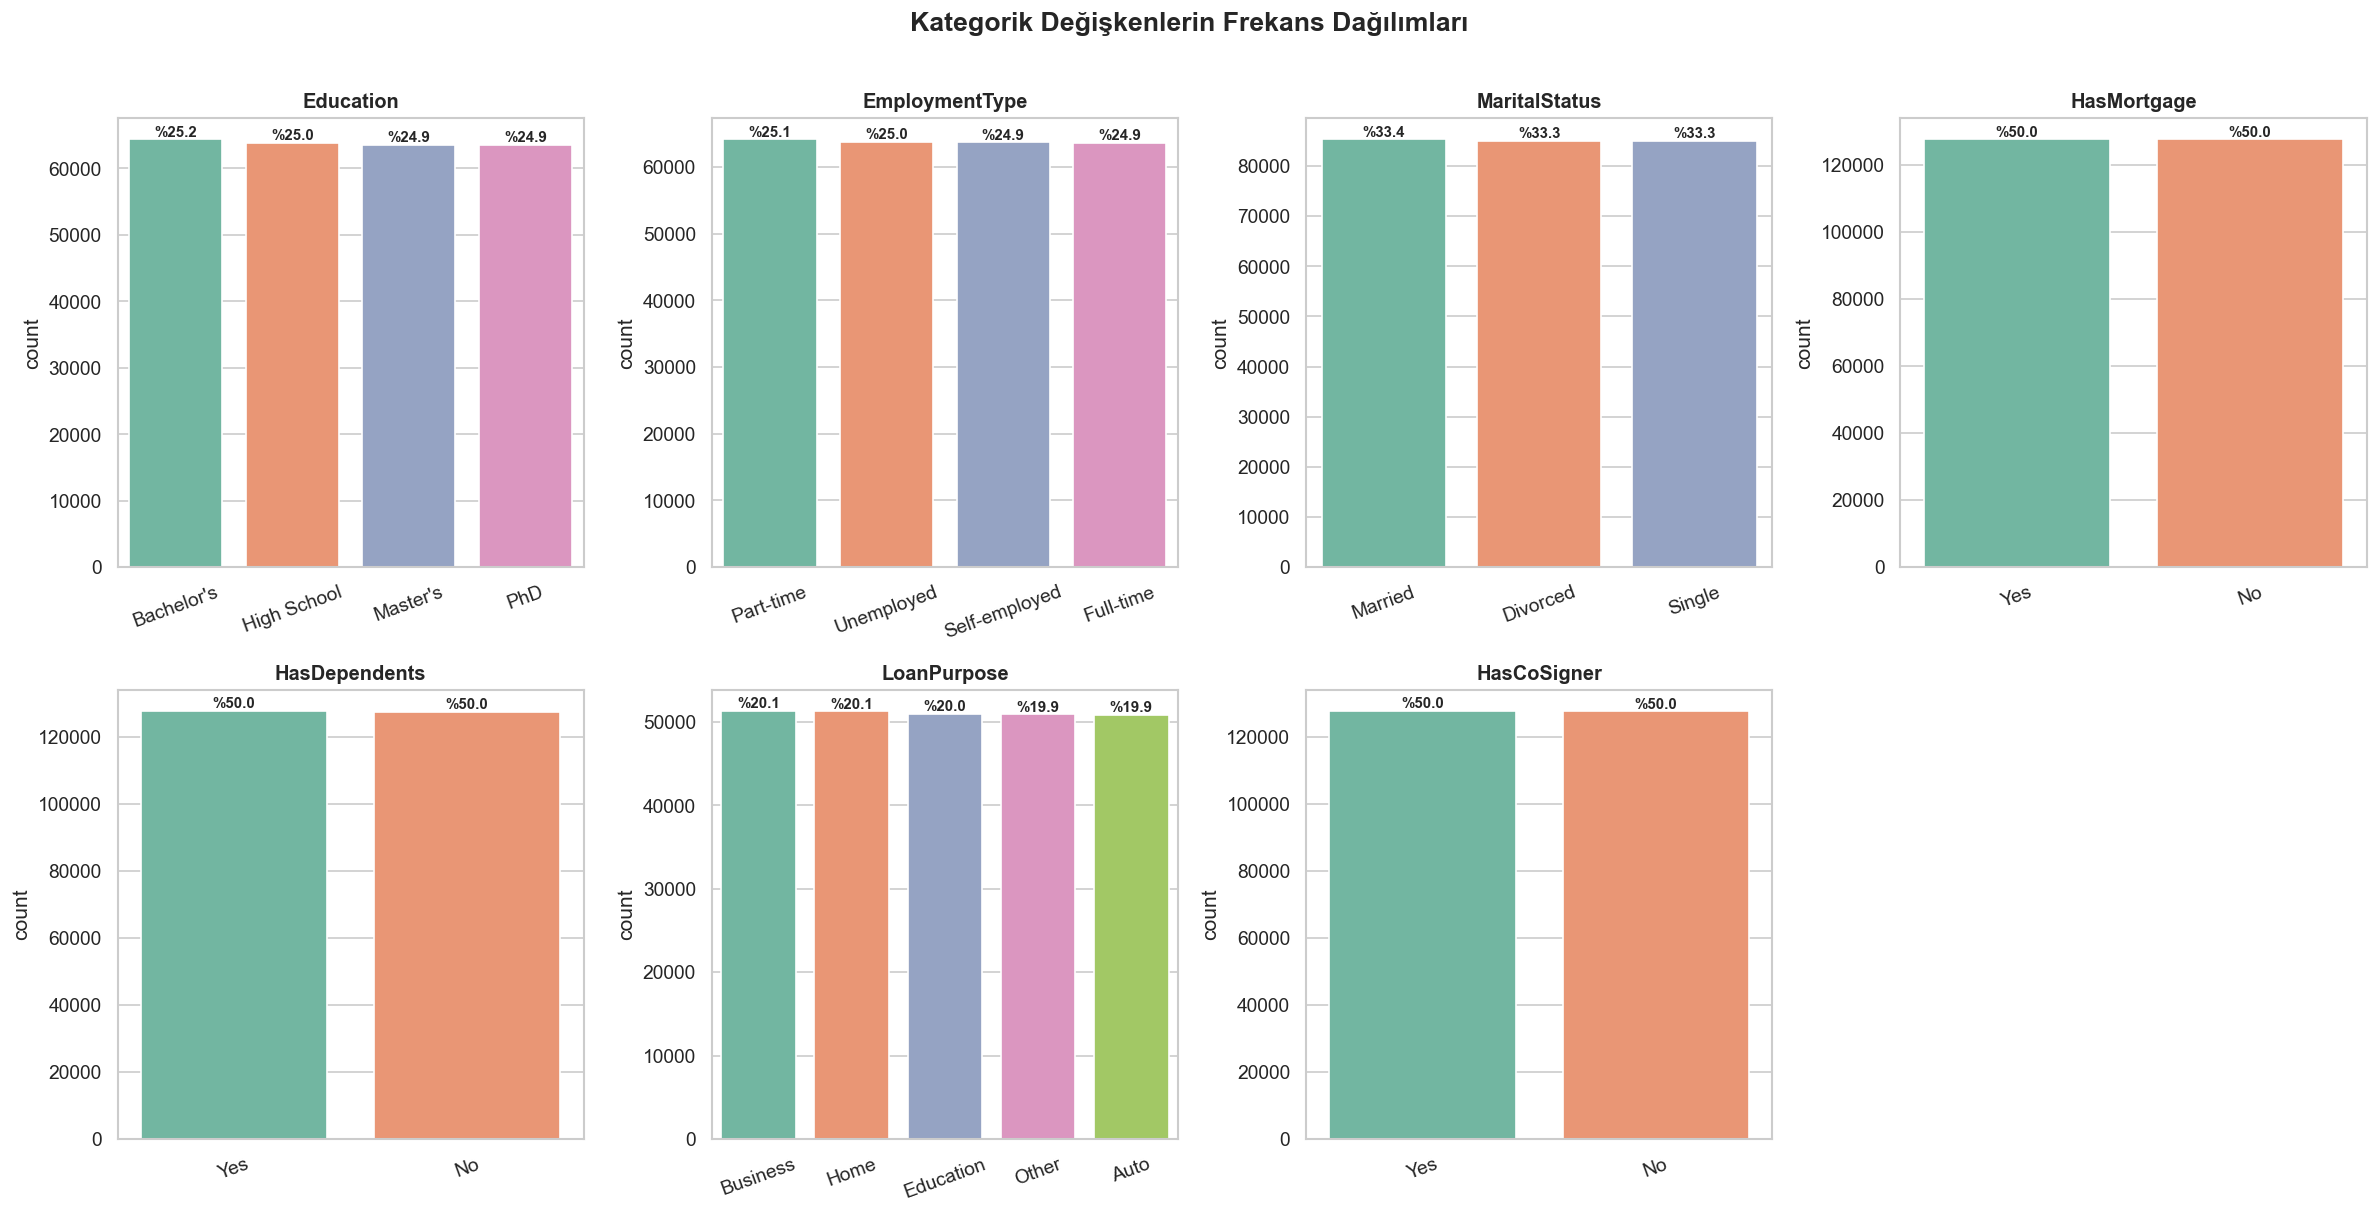

In [12]:
# ---------------------------------------------------------------------------
# Kategorik sütunlar — Frekans grafikleri
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLS):
    ax = axes[i]
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, palette="Set2", edgecolor="white")
    
    # Barların üstüne yüzde yaz
    total = len(df)
    for p in ax.patches:
        pct = p.get_height() / total * 100
        ax.annotate(
            f"%{pct:.1f}",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

# Fazla subplot'u gizle
axes[-1].set_visible(False)

fig.suptitle("Kategorik Değişkenlerin Frekans Dağılımları", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}03_categorical_distributions.png")
plt.show()

---
## 7. İki Değişkenli Analiz — Sayısal Sütunlar vs Hedef

Her sayısal değişkenin Default=0 ve Default=1 gruplarındaki dağılımını karşılaştırıyoruz.
Bu, hangi özelliklerin temerrütle güçlü ilişkisi olduğunu anlamamıza yardımcı olur.

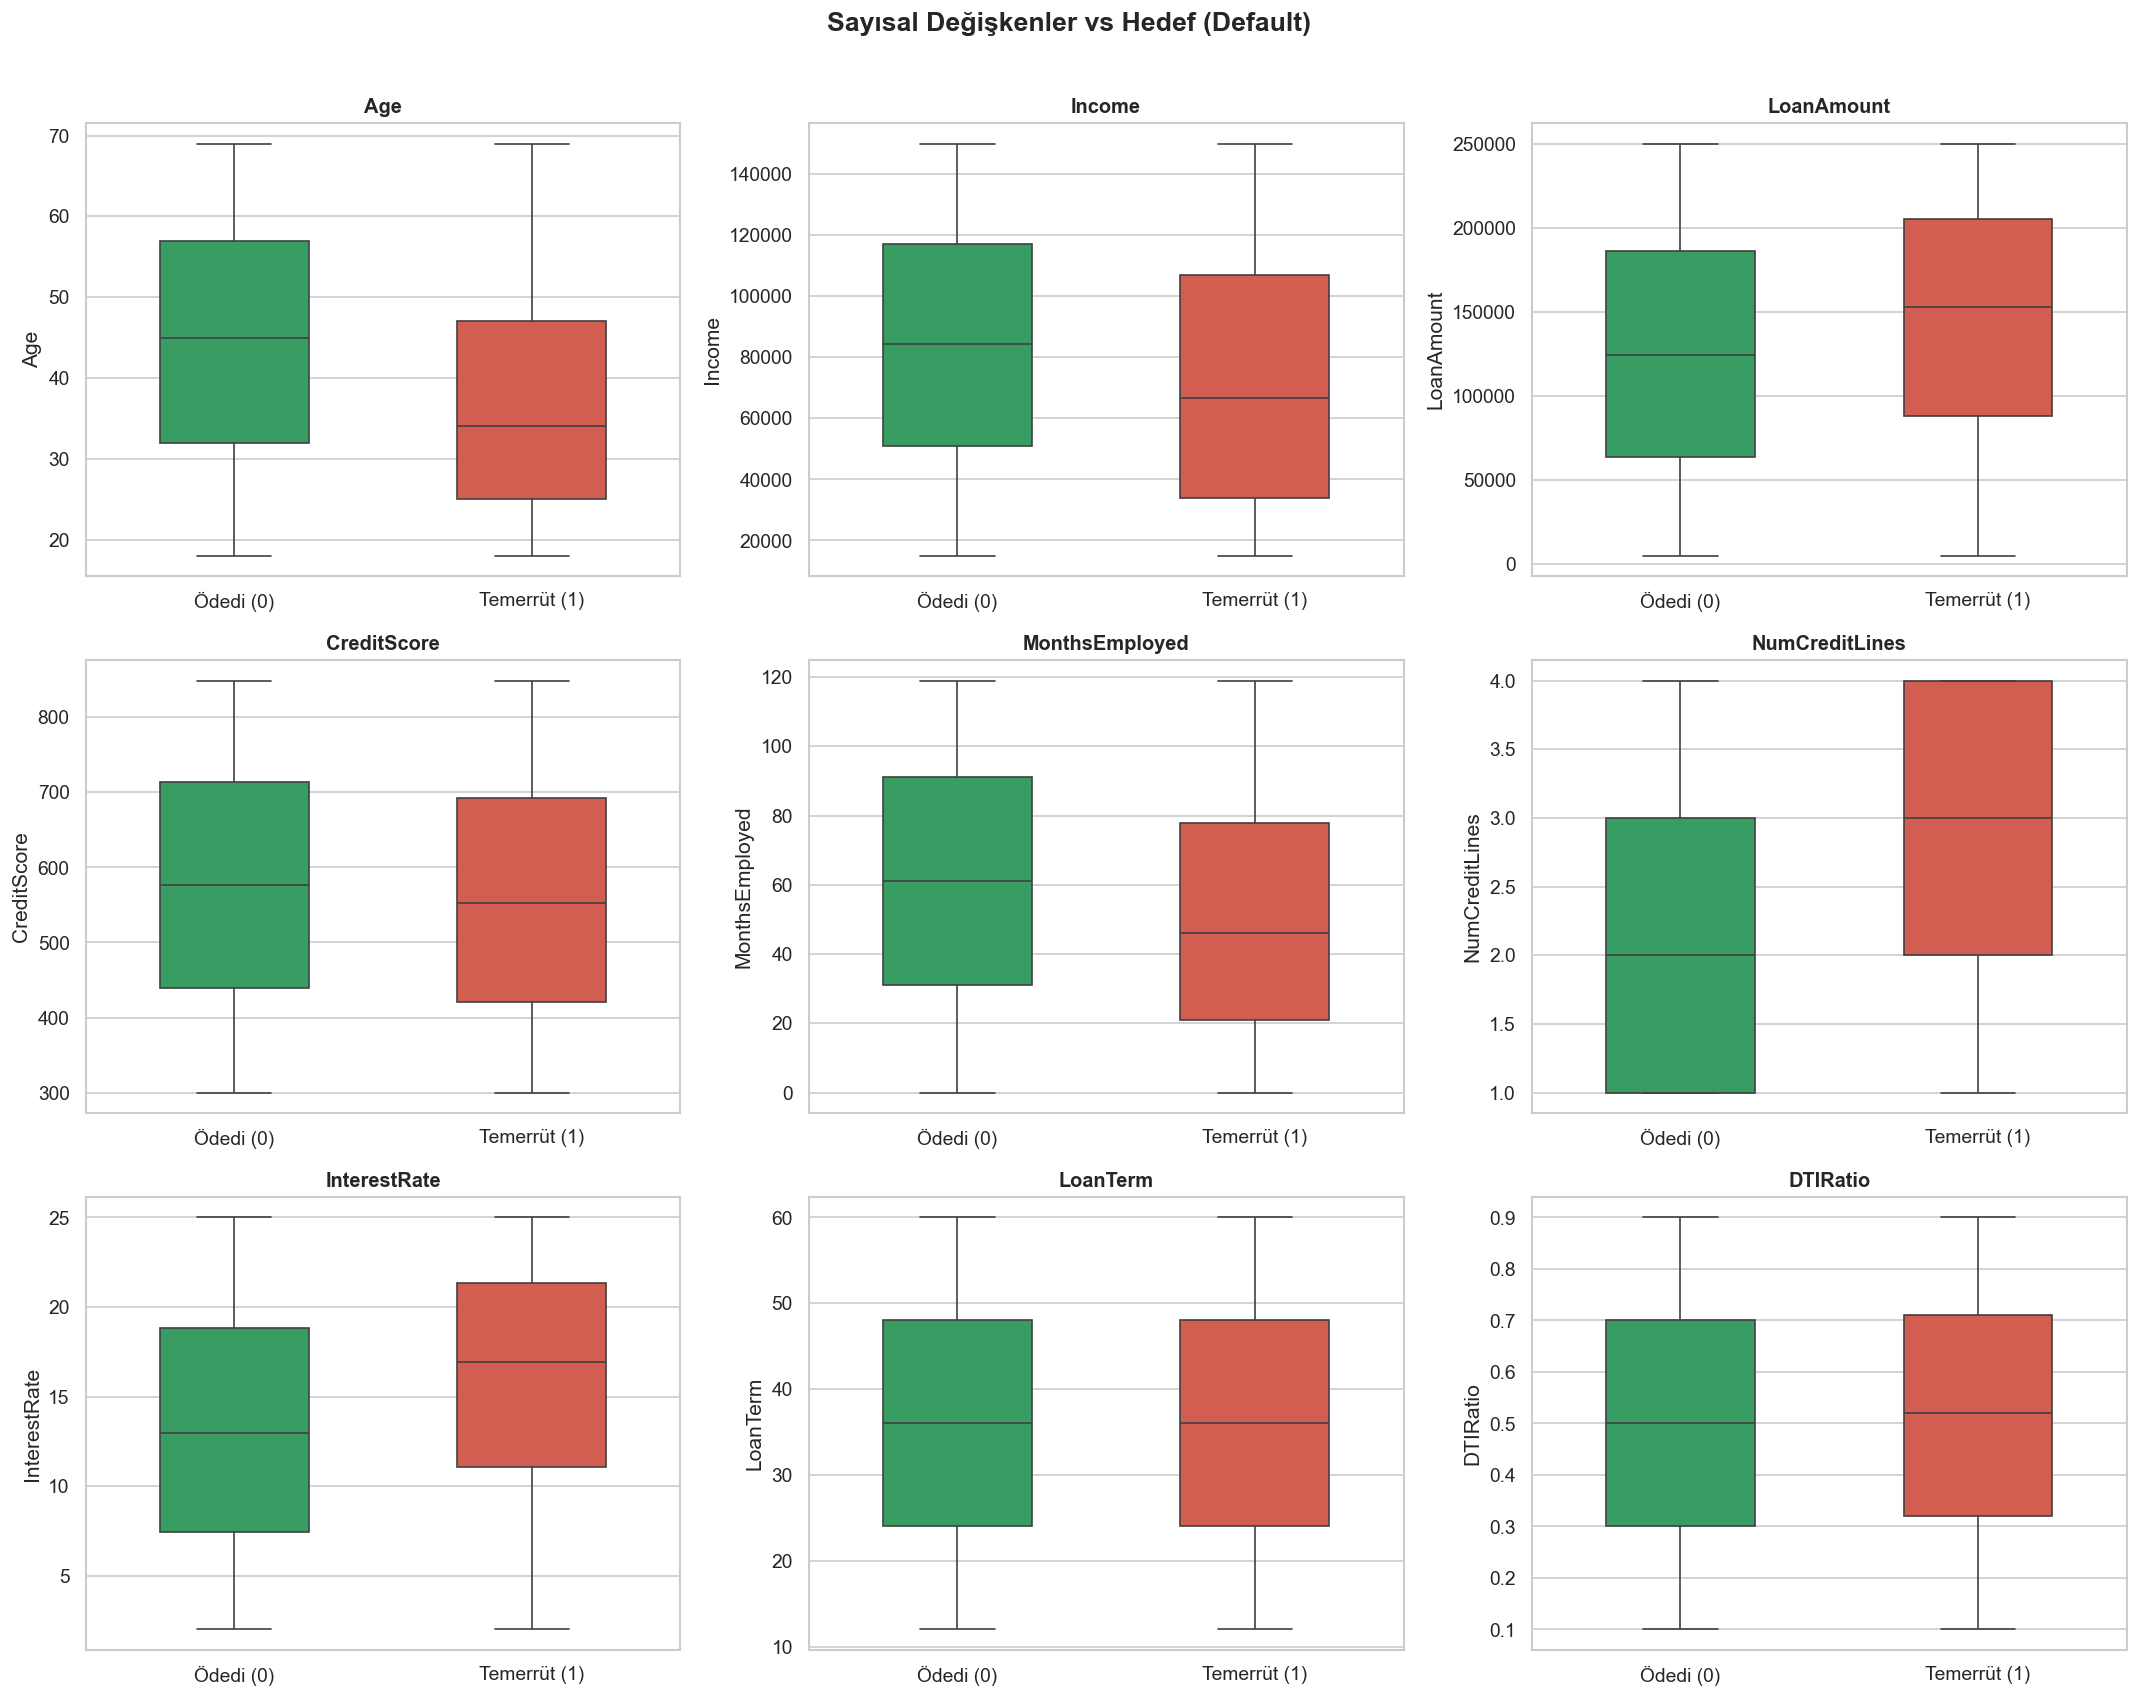

In [13]:
# ---------------------------------------------------------------------------
# Sayısal vs Hedef — Boxplot grid (3x3)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_COLS):
    ax = axes[i]
    sns.boxplot(
        data=df, x=TARGET_COL, y=col, ax=ax,
        palette=TARGET_COLORS, width=0.5,
        flierprops=dict(marker="o", markersize=2, alpha=0.3)
    )
    ax.set_xticklabels(["Ödedi (0)", "Temerrüt (1)"])
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel("")

fig.suptitle("Sayısal Değişkenler vs Hedef (Default)", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}04_numerical_vs_target.png")
plt.show()

In [14]:
# ---------------------------------------------------------------------------
# Grup ortalamaları karşılaştırması
# ---------------------------------------------------------------------------
group_means = df.groupby(TARGET_COL)[NUMERICAL_COLS].mean().T
group_means.columns = ["Ödedi (0)", "Temerrüt (1)"]
group_means["Fark (%)"] = ((group_means["Temerrüt (1)"] - group_means["Ödedi (0)"]) / group_means["Ödedi (0)"] * 100).round(2)
group_means.round(2)

,Ödedi (0),Temerrüt (1),Fark (%)
Age,44.41,36.56,-17.68
Income,83899.17,71844.72,-14.37
LoanAmount,125353.66,144515.31,15.29
CreditScore,576.23,559.29,-2.94
MonthsEmployed,60.76,50.24,-17.33
NumCreditLines,2.49,2.59,3.97
InterestRate,13.18,15.90,20.64
LoanTerm,36.02,36.05,0.08
DTIRatio,0.50,0.51,2.78


---
## 8. İki Değişkenli Analiz — Kategorik Sütunlar vs Hedef

Her kategorideki **temerrüt oranını** (default rate) hesaplayarak hangi kategorilerin daha riskli olduğunu belirliyoruz.

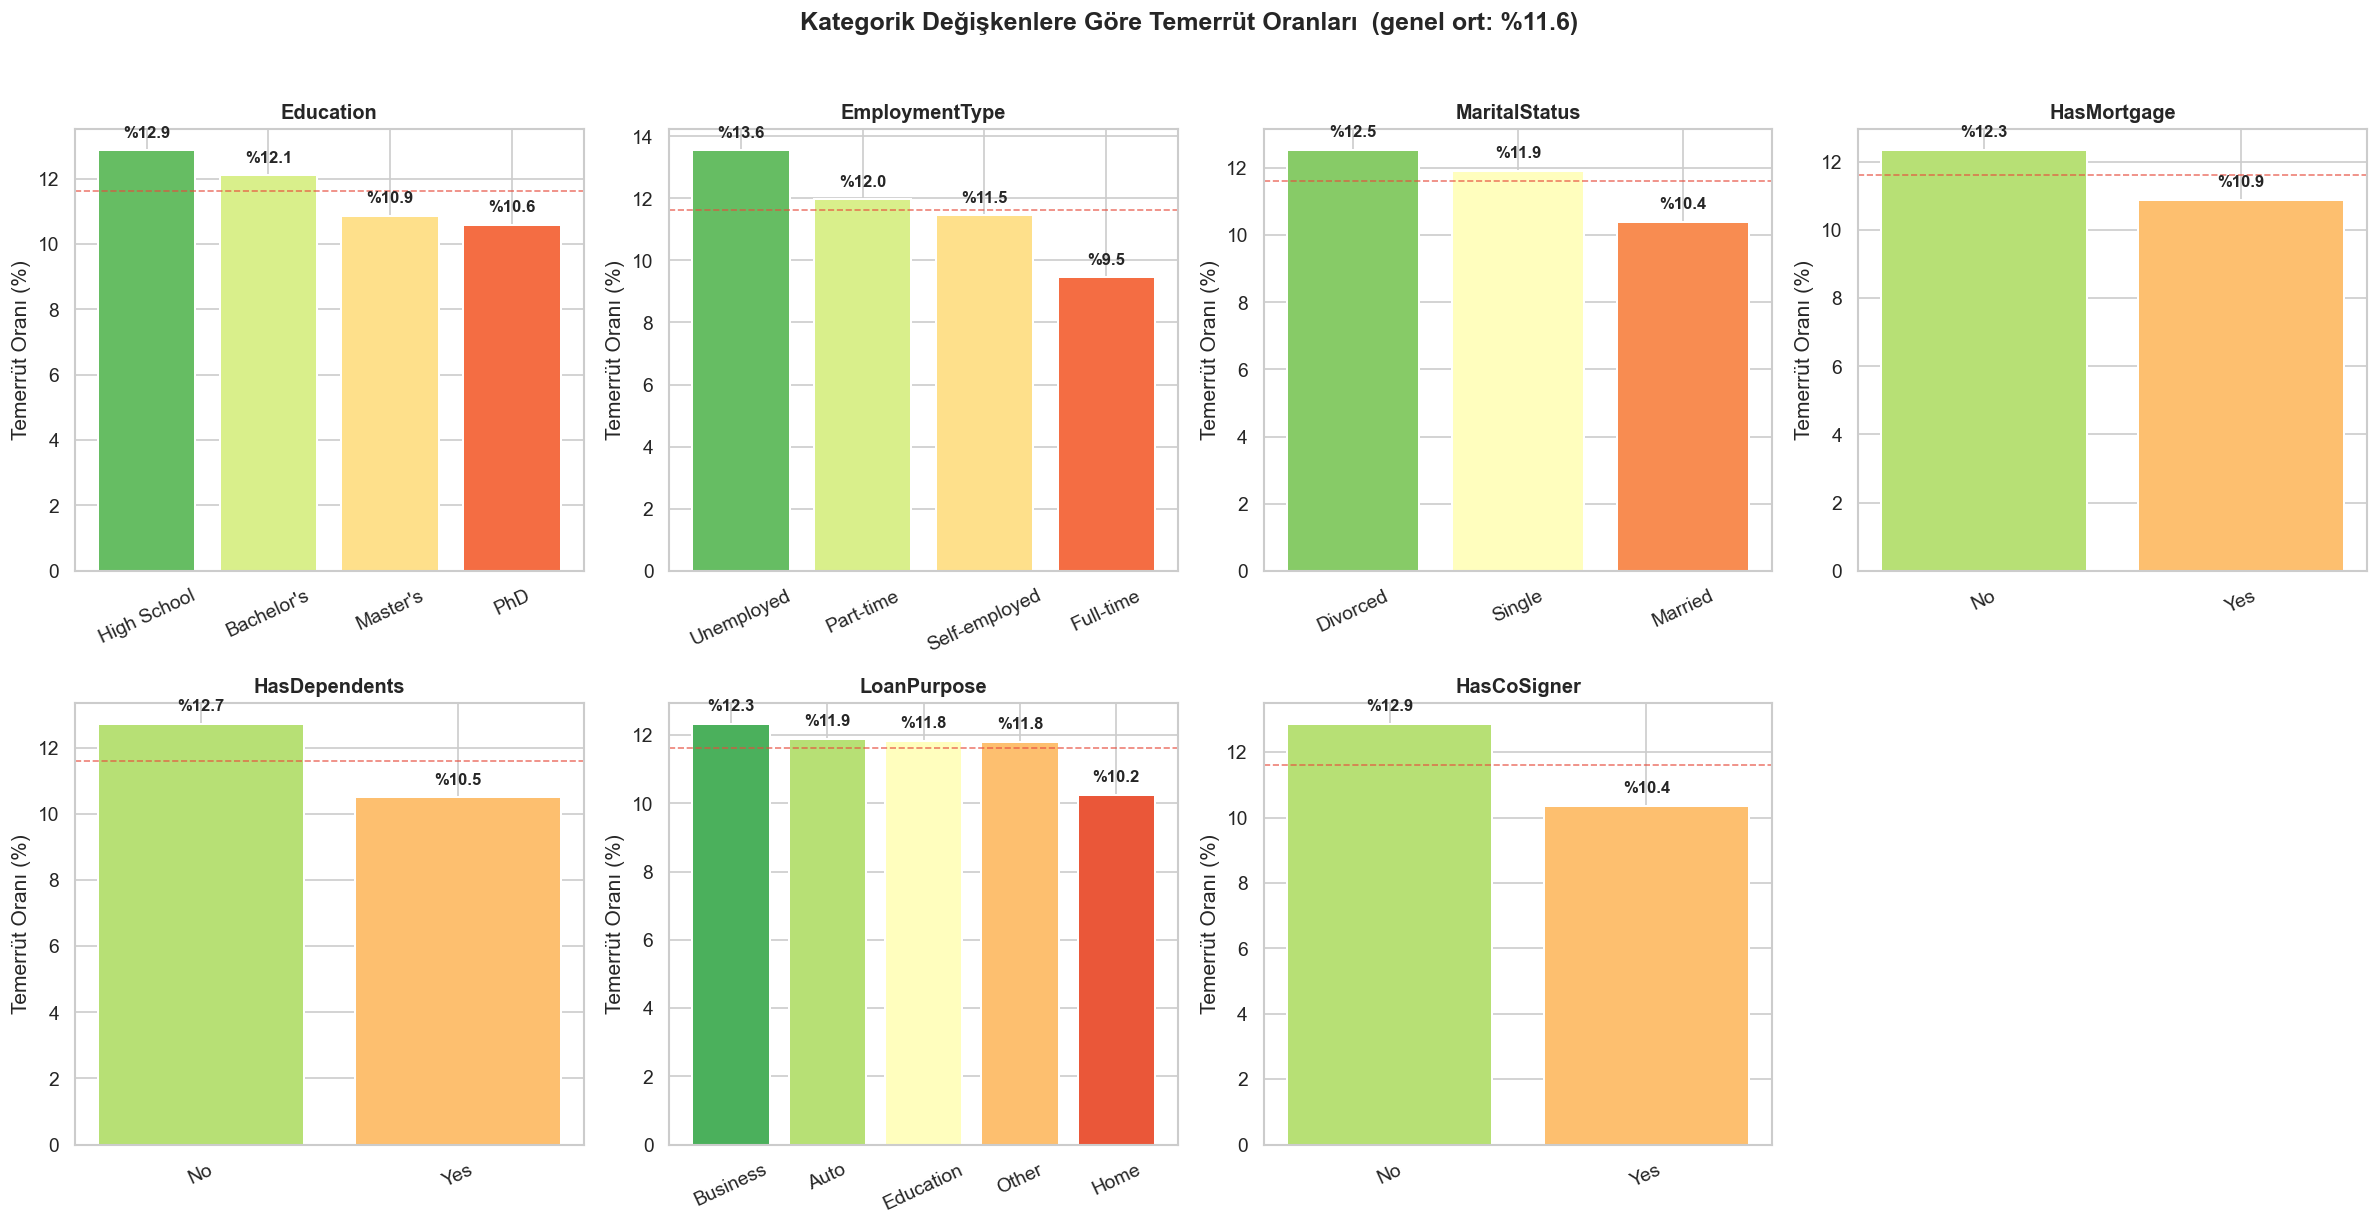

In [15]:
# ---------------------------------------------------------------------------
# Kategorik vs Hedef — Temerrüt oranları
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(CATEGORICAL_COLS):
    ax = axes[i]
    
    # Her kategori için temerrüt oranı hesapla
    default_rate = df.groupby(col)[TARGET_COL].mean().sort_values(ascending=False)
    
    bars = ax.bar(
        default_rate.index, default_rate.values * 100,
        color=sns.color_palette("RdYlGn_r", len(default_rate)),
        edgecolor="white", linewidth=1.2
    )
    
    # Barların üstüne oran yaz
    for bar, rate in zip(bars, default_rate.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"%{rate * 100:.1f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold"
        )
    
    ax.set_title(f"{col}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Temerrüt Oranı (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    
    # Genel ortalama çizgisi
    overall_rate = df[TARGET_COL].mean() * 100
    ax.axhline(overall_rate, color="#e74c3c", linestyle="--", linewidth=1, alpha=0.7)

# Fazla subplot'u gizle
axes[-1].set_visible(False)

fig.suptitle(
    f"Kategorik Değişkenlere Göre Temerrüt Oranları  (genel ort: %{overall_rate:.1f})",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}05_categorical_vs_target.png")
plt.show()

---
## 9. Korelasyon Analizi

Sayısal değişkenler arasındaki doğrusal ilişkileri (Pearson korelasyonu) ısı haritası ile inceliyoruz.
Yüksek korelasyonlu çiftler çoklu doğrusal bağlantı (multicollinearity) riski taşır.

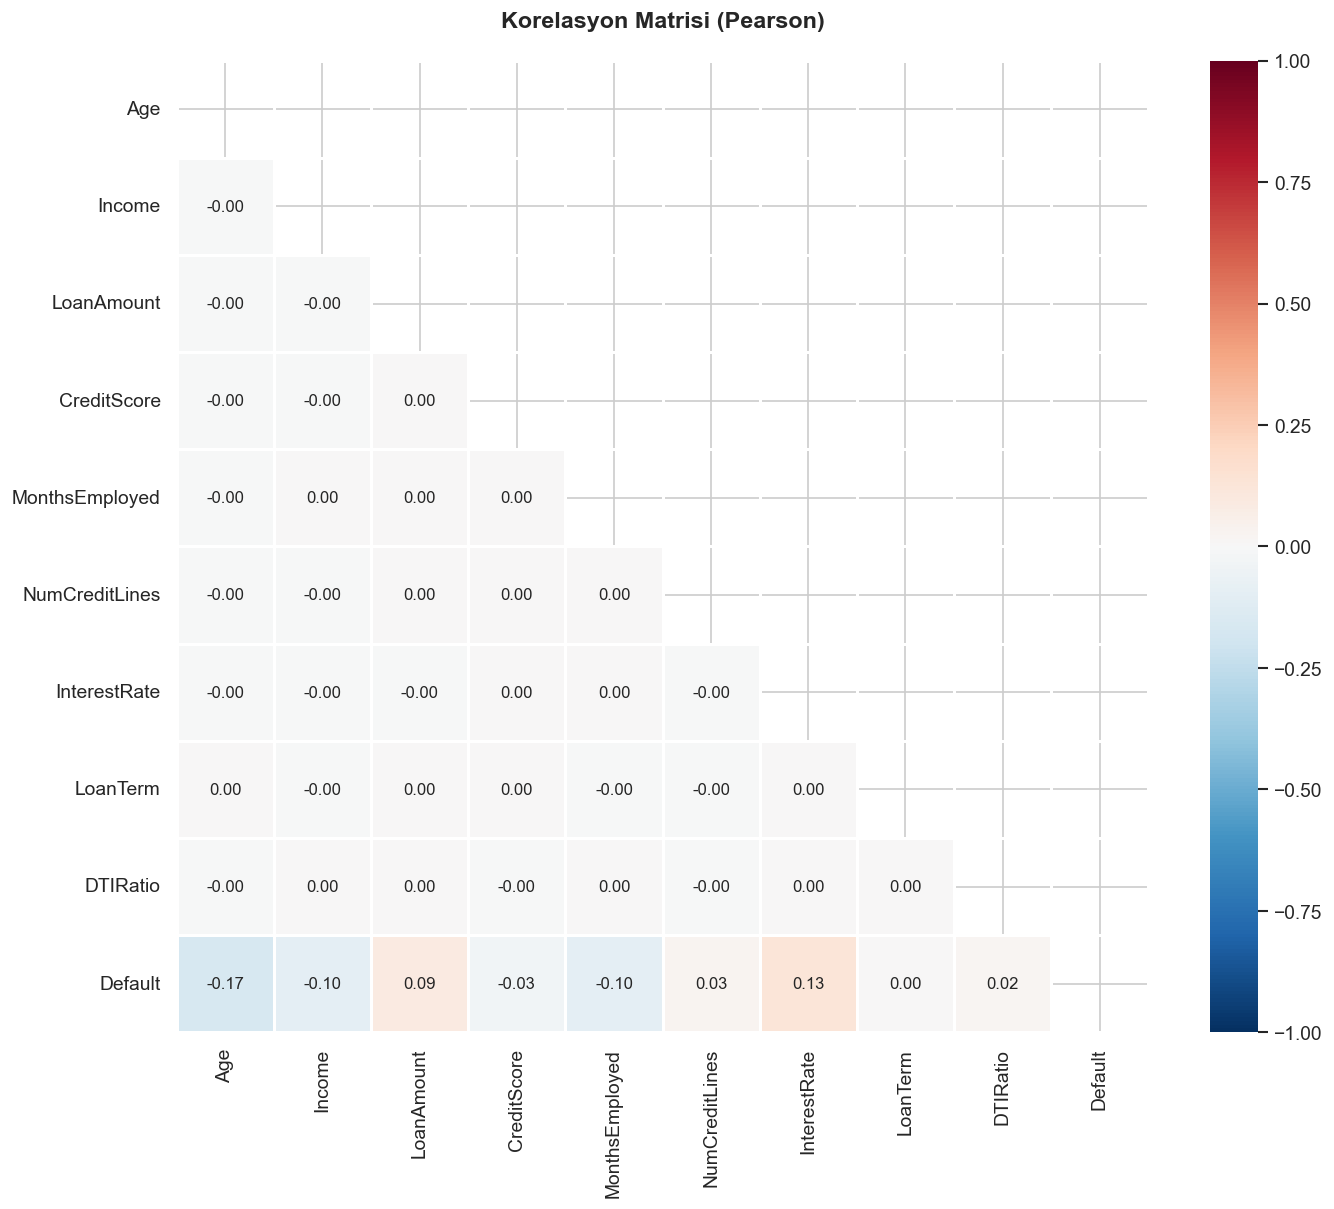


📌 En yüksek korelasyonlu çiftler (|r| > 0.3):
  → |r| > 0.3 olan çift bulunamadı. Multicollinearity riski düşük. ✅


In [16]:
# ---------------------------------------------------------------------------
# Korelasyon matrisi — Alt üçgen ısı haritası
# ---------------------------------------------------------------------------
corr_cols = NUMERICAL_COLS + [TARGET_COL]
corr_matrix = df[corr_cols].corr()

# Alt üçgen maskesi
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.8,
    ax=ax,
    annot_kws={"size": 10}
)
ax.set_title("Korelasyon Matrisi (Pearson)", fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}06_correlation_heatmap.png")
plt.show()

# En yüksek korelasyonlar (Target hariç)
print("\n📌 En yüksek korelasyonlu çiftler (|r| > 0.3):")
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ["Var1", "Var2", "Correlation"]
corr_pairs = corr_pairs[
    (corr_pairs["Var1"] != corr_pairs["Var2"]) &
    (abs(corr_pairs["Correlation"]) > 0.3)
].drop_duplicates(subset=["Correlation"]).sort_values("Correlation", key=abs, ascending=False)

if len(corr_pairs) > 0:
    print(corr_pairs.to_string(index=False))
else:
    print("  → |r| > 0.3 olan çift bulunamadı. Multicollinearity riski düşük. ✅")

---
## 10. Aykırı Değer (Outlier) Tespiti

IQR (Interquartile Range) yöntemiyle her sayısal sütundaki aykırı değerleri tespit ediyoruz.

**Formül:**
- Q1 = 25. yüzdelik, Q3 = 75. yüzdelik
- IQR = Q3 − Q1
- Alt sınır = Q1 − 1.5 × IQR
- Üst sınır = Q3 + 1.5 × IQR

In [17]:
# ---------------------------------------------------------------------------
# IQR tabanlı aykırı değer analizi
# ---------------------------------------------------------------------------
def detect_outliers_iqr(dataframe, column, threshold=1.5):
    """IQR yöntemiyle aykırı değerleri tespit eder."""
    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - threshold * iqr
    upper_bound = q3 + threshold * iqr
    
    outlier_mask = (dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)
    outlier_count = outlier_mask.sum()
    outlier_pct = outlier_count / len(dataframe) * 100
    
    return {
        "Column": column,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": outlier_count,
        "Outlier (%)": round(outlier_pct, 2)
    }

# Tüm sayısal sütunlar için aykırı değer raporu
outlier_results = [detect_outliers_iqr(df, col) for col in NUMERICAL_COLS]
outlier_df = pd.DataFrame(outlier_results).set_index("Column")
outlier_df.sort_values("Outlier (%)", ascending=False)

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier (%)
Column,,,,,,,
Age,31.00,56.00,25.00,-6.50,93.50,0,0.0
Income,48825.50,116219.00,67393.50,-52264.75,217309.25,0,0.0
LoanAmount,66156.00,188985.00,122829.00,-118087.50,373228.50,0,0.0
CreditScore,437.00,712.00,275.00,24.50,1124.50,0,0.0
MonthsEmployed,30.00,90.00,60.00,-60.00,180.00,0,0.0
NumCreditLines,2.00,3.00,1.00,0.50,4.50,0,0.0
InterestRate,7.77,19.25,11.48,-9.45,36.47,0,0.0
LoanTerm,24.00,48.00,24.00,-12.00,84.00,0,0.0
DTIRatio,0.30,0.70,0.40,-0.30,1.30,0,0.0


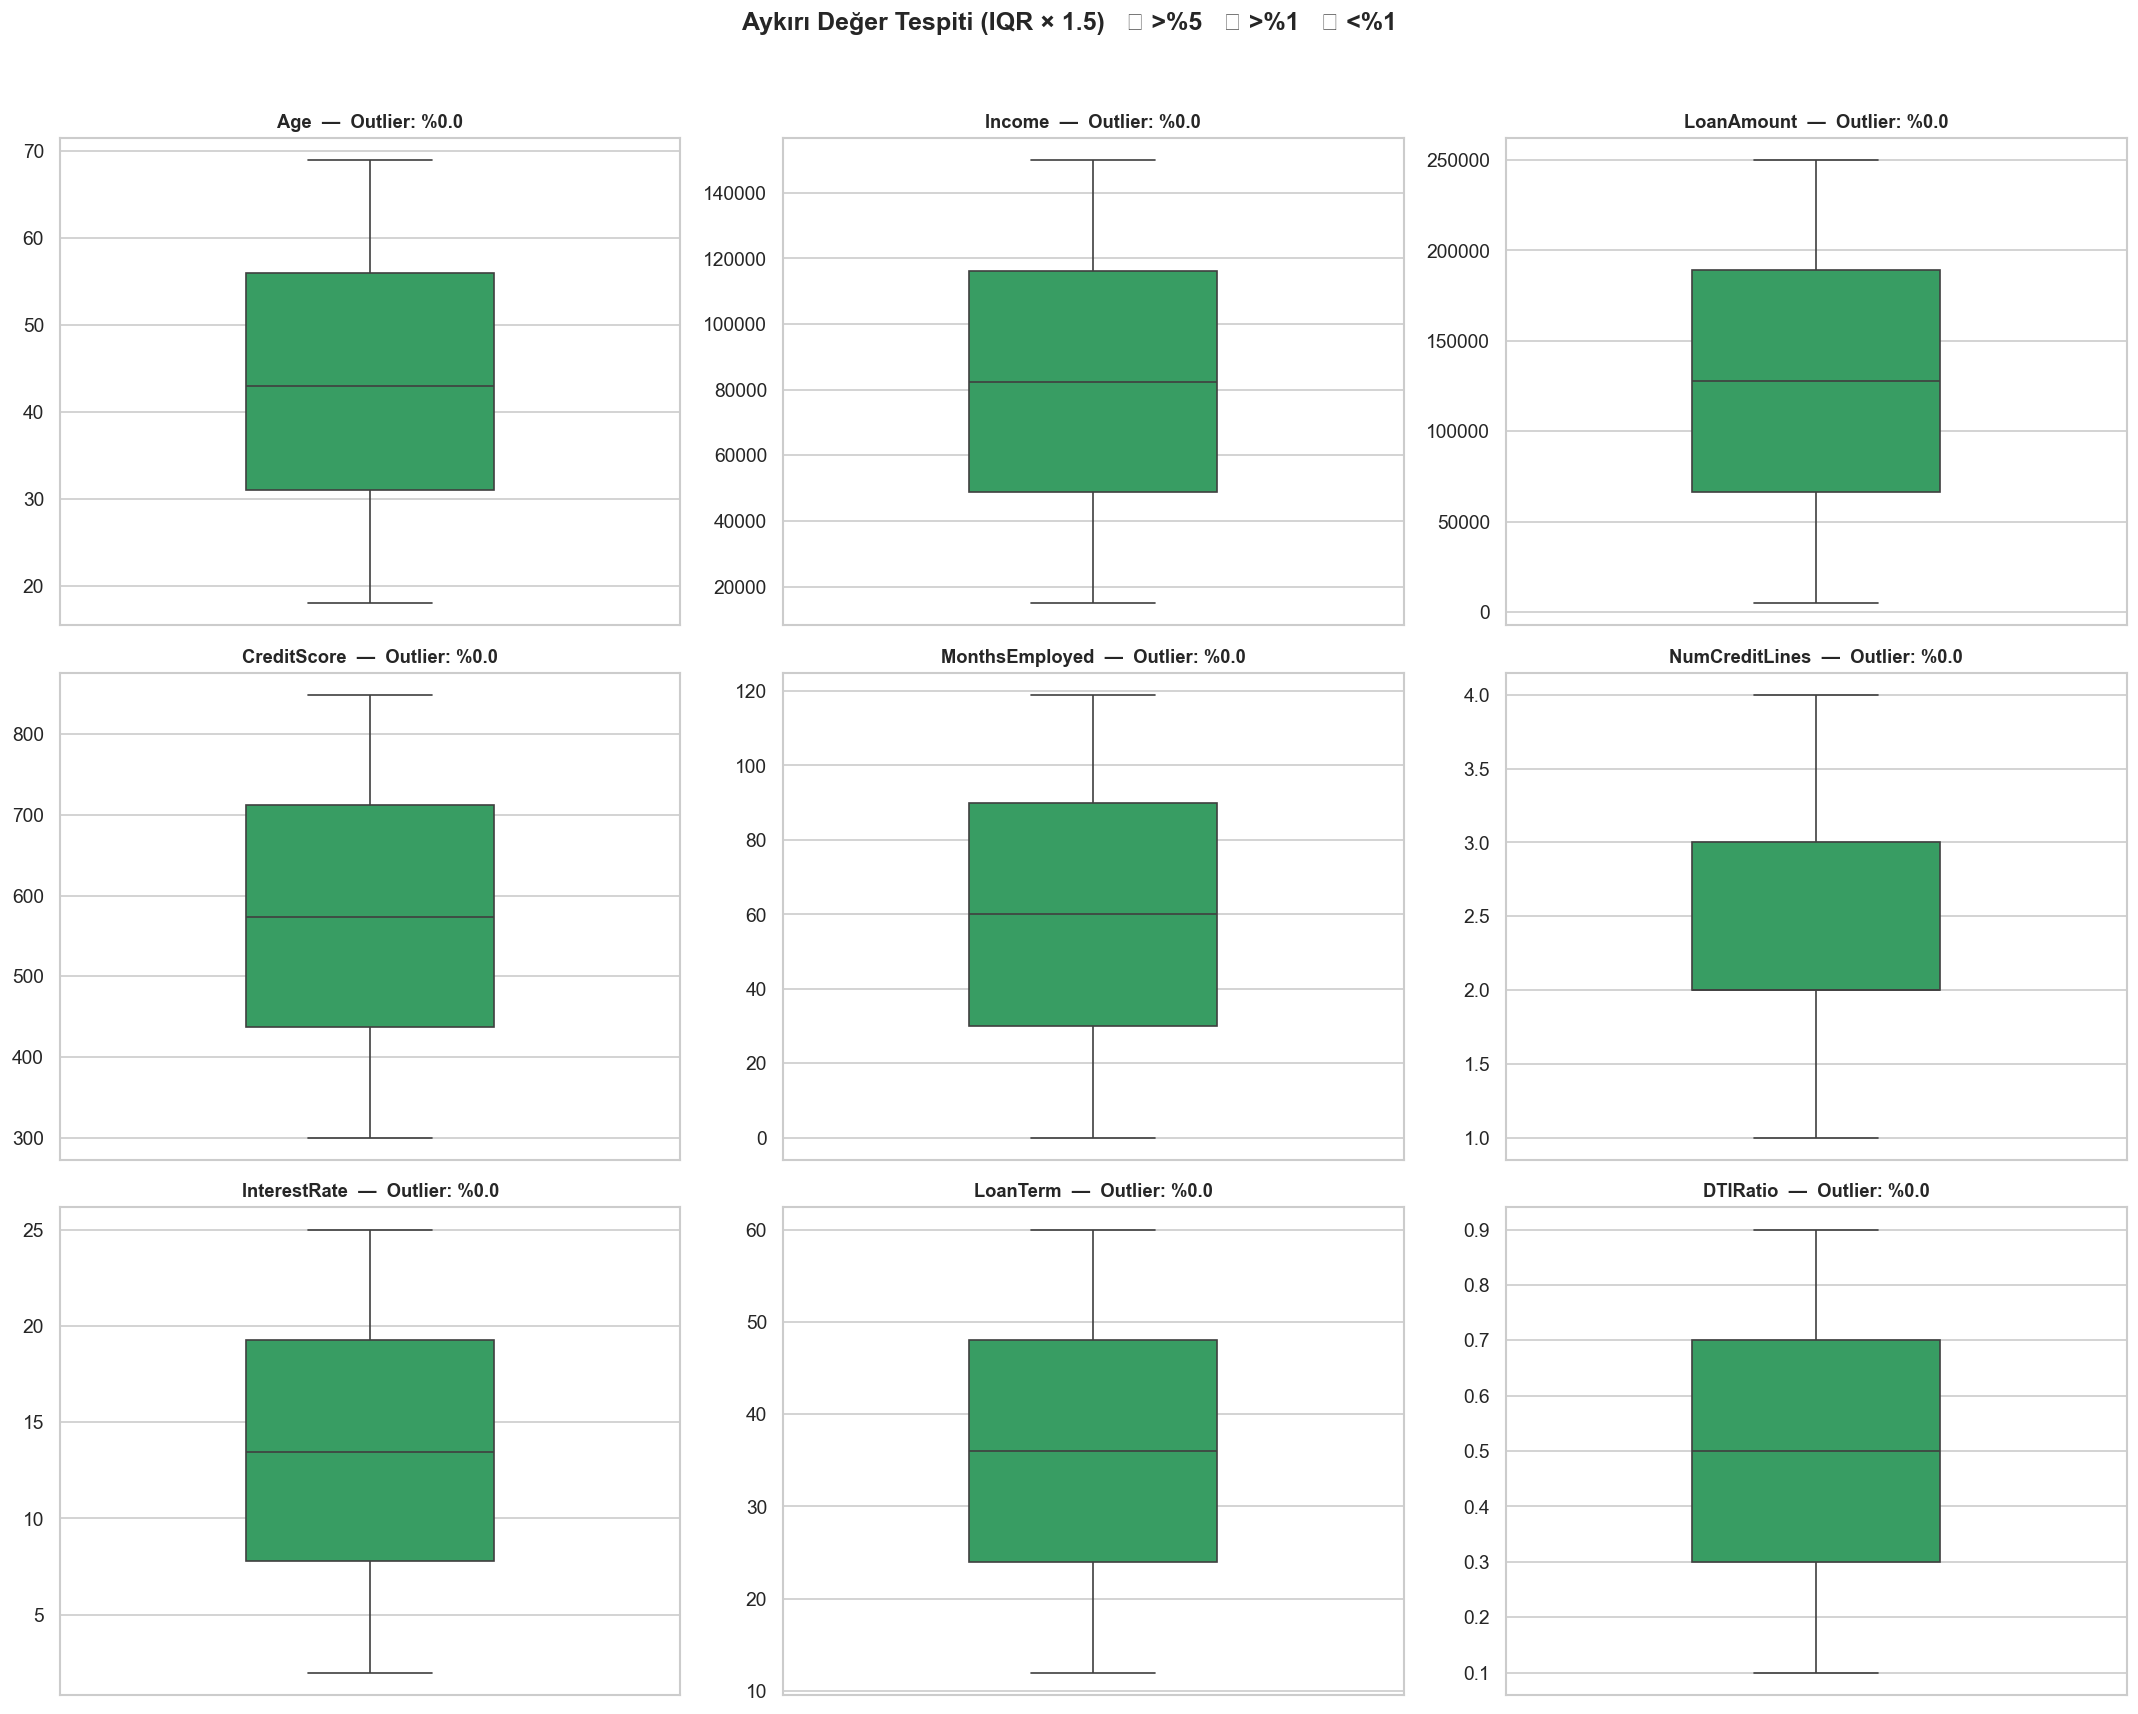

In [18]:
# ---------------------------------------------------------------------------
# Aykırı değer görselleştirmesi — Boxplot grid
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(NUMERICAL_COLS):
    ax = axes[i]
    
    # Outlier bilgisi
    info = outlier_results[i]
    outlier_pct = info["Outlier (%)"]
    
    color = "#e74c3c" if outlier_pct > 5 else "#f39c12" if outlier_pct > 1 else "#27ae60"
    
    sns.boxplot(data=df, y=col, ax=ax, color=color, width=0.4,
                flierprops=dict(marker="o", markersize=3, alpha=0.4))
    
    ax.set_title(f"{col}  —  Outlier: %{outlier_pct:.1f}", fontsize=11, fontweight="bold")
    ax.set_ylabel("")

fig.suptitle(
    "Aykırı Değer Tespiti (IQR × 1.5)   🔴 >%5   🟡 >%1   🟢 <%1",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}07_outlier_boxplots.png")
plt.show()

---
## 11. Çok Değişkenli İlişkiler — Pairplot

Hedef değişkenle en ilgili olabilecek seçili değişkenlerin ikili ilişkilerini inceliyoruz.

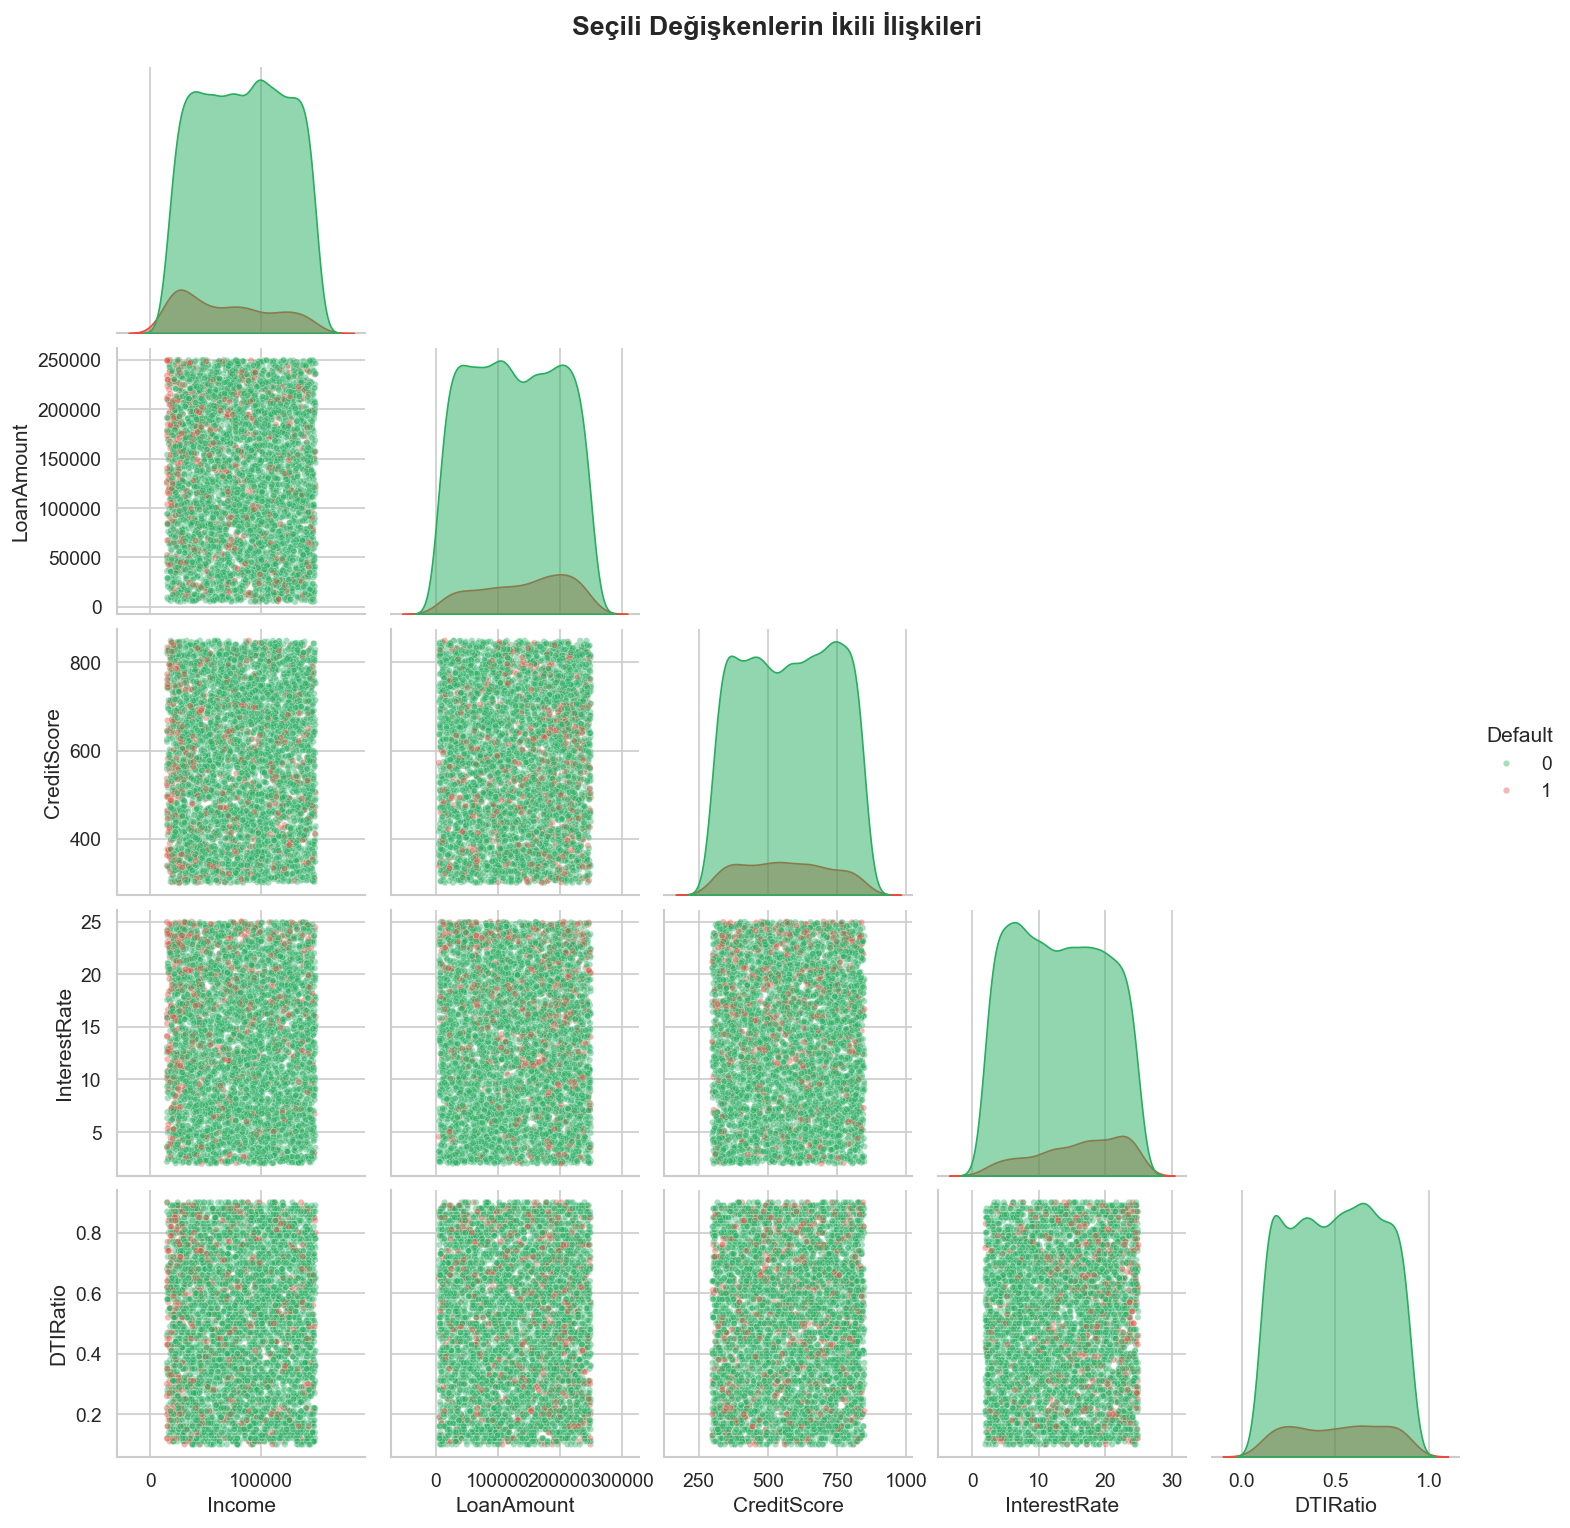

In [19]:
# ---------------------------------------------------------------------------
# Seçili değişkenler için pairplot
# ---------------------------------------------------------------------------
selected_cols = ["Income", "LoanAmount", "CreditScore", "InterestRate", "DTIRatio", TARGET_COL]

pair_sample = df[selected_cols].sample(n=5000, random_state=42)  # Performans için örnekle

g = sns.pairplot(
    pair_sample,
    hue=TARGET_COL,
    palette=TARGET_COLORS,
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15},
    diag_kws={"fill": True, "alpha": 0.5},
    corner=True
)
g.figure.suptitle("Seçili Değişkenlerin İkili İlişkileri", fontsize=16, fontweight="bold", y=1.02)

plt.savefig(f"{FIGURES_DIR}08_pairplot.png")
plt.show()

---
## 12. 📋 Bulgular & Özet

### Veri Kalitesi
- ✅ Eksik değer yok — Imputation gerekmez
- ✅ Tekrar eden satır/ID yok
- ⚠️ Bazı sayısal sütunlarda aykırı değerler mevcut (yukarıdaki tabloya bakınız)

### Sınıf Dengesizliği
- ⚠️ **Ciddi dengesizlik:** %88.4 vs %11.6 (yaklaşık 7.6:1 oranında)
- 📌 **Modelleme stratejisi:** `class_weight="balanced"` veya SMOTE (imbalanced-learn) kullanılmalı

### Özellik Dağılımları
- Sayısal değişkenlerin çoğu **simetrik dağılmış** (düşük çarpıklık)
- Kategorik değişkenler dengeli dağılımlara sahip

### Korelasyon
- Değişkenler arasında güçlü multicollinearity görülmedi (çoğu |r| < 0.3)
- Hedef değişkenle çok güçlü tek bir korelasyon yok → **ensemble modeller** (XGBoost) faydalı olacak

### Sonraki Adım
Bu bulgular ışığında `02_preprocessing.ipynb` notebook'unda:
1. Aykırı değerleri IQR ile kırpma (winsorize/clip)
2. Kategorik değişkenleri encode etme (Label/One-Hot)
3. Sayısal değişkenleri ölçeklendirme (StandardScaler)
4. Train/Test split (%80/%20, stratified)
5. Temizlenmiş veriyi `data/processed/` klasörüne kaydetme

---
*Analiz tamamlandı. Oluşturulan grafikler `reports/figures/` klasörüne kaydedilmiştir.*